## Import related functions

In [1]:
cd("c:\\Disk_D\\Master Research\\Research-Project")

In [2]:
include(joinpath(@__DIR__,"..", "Helper_util", "util.jl"))
include(joinpath(@__DIR__, "..", "Parameter", "parameter.jl"));

In [3]:
## Define the diffusion coefficients and wave WaveNumber
diffusion_coefficient = DiffusionParameter(1, 0.0001, 0.001, 0.0001)

total_population=Total_Population(0.4).total

## parameter setting up 2
Nₜ = global_parameter_1.Nₜ
λ, ν, m = global_parameter_1.λ, global_parameter_1.ν, global_parameter_1.m
d₁, d₂, k = diffusion_coefficient.d₁, diffusion_coefficient.d₂, WaveNumber(4).k;

## Useful util for 2D simulation

In [4]:
function lhs_term(λ, ν)
    return N -> (ν/λ)*N / (N + 1)
end
function rhs_term(N_t, m)
    return N -> (N_t - N)^(m-1)
end;



function visulize_equilibrium_state_2D(N_t,λ,ν,m)
    lhs = lhs_term(λ, ν)
    rhs = rhs_term(N_t, m)

    # Generate range of N values
    N_vals = range(0, N_t-0.01, length=500)

    # Evaluate functions
    lhs_vals = lhs.(N_vals)
    rhs_vals = rhs.(N_vals)

    # Find intersection numerically
    f_diff = N -> lhs(N) - rhs(N)

    root = find_zero(f_diff, (0, 0.01), verbose=false)

    
    # Plot
    p=plot(N_vals, lhs_vals, label = "LHS", lw=2, xlims=(0, 0.05),ylims=(0, 10),title = "m = $m, root ≈ $root")
    plot!(N_vals, rhs_vals, label = "RHS", lw=2, linestyle=:dash)
    ## display(p)
    return root
end



function equilibrium_state_2D(N_t,λ,ν,m)
    ## record the length of vector N_t
    num_pt=length(N_t)
    # Pre-define the vector P_star and N_star as vector to store the equilibrium values for each N_t[i]
    P̄,N̄=zeros(Float64,num_pt),zeros(Float64,num_pt)

    # running the for loop for every N_t
    for i in 1:num_pt
       N̄[i]= visulize_equilibrium_state_2D(N_t[i],λ,ν,m)
       P̄[i]=N_t[i]-N̄[i]

       ## if there is no such real roots in the restricted range [0,N_t[i]], we use -1 to denote N and P
       if 0 <= N̄[i] && N̄[i] <= N_t[i] && 0 <= P̄[i] && P̄[i] <= N_t[i]
           continue
       else
           N̄[i]= -1
           P̄[i]= -1
       end
   end
   
   return(N̄,P̄)
end


function ODE_PDE_system_2D(Nₜ,λ,ν,m,d₁,d₂,k)

    N̄,P̄=equilibrium_state_2D(Nₜ,λ,ν,m)
    result=[]
    for i in 1:length(Nₜ)
        Nᵢ,Pᵢ=N̄[i],P̄[i]
        if Nᵢ == -1 && Pᵢ==-1
           key=[-NaN,-NaN, Nₜ[i]]
        else
           ## Define the Jacobian matrix at equilibrium states
           A=zeros(2,2)
           A=[-ν*Pᵢ/((1+Nᵢ)^2)   (m-1)*λ*Pᵢ^(m-1)
               ν*Pᵢ/((1+Nᵢ)^2)   -(m-1)*λ*Pᵢ^(m-1)]
           ## define the linear approximation matrix for PDE system
           diffusion_vec=[d₁,d₂]
           diffusion_mat=diagm(0 => -(k^2)*diffusion_vec)
           pde_mat=A+diffusion_mat
           ode_mat=A
           eigen_pde=eigen(pde_mat).values
           ## define the maximum of real part of eigenvalue
           key_eigen_pde = maximum(real(eigen_pde))
           max_index= argmax(real(eigen_pde))

           eigen_ode=eigen(ode_mat).values
           key_eigen_ode = maximum(real(eigen_ode))
           ## define the eigenvector corresponding to the largest eigenvalue
           eigen_vec=(eigen(pde_mat).vectors)[:,max_index]
           
           key=[key_eigen_ode,key_eigen_pde,Nₜ[i],eigen_vec]
           
        end
        push!(result,key)
    end
    return(result)
end


function plot_pde_eigenvalues_2D(Nₜ, λ, ν, m, d₁, d₂, k_range, xlim_range, ylim_range)
    eigen_pde_values = []
    
    for k in k_range
        result = ODE_PDE_system_2D(Nₜ, λ, ν, m, d₁, d₂,k)[1]
        push!(eigen_pde_values, result[2])
    end

    # Plot max real part of PDE eigenvalue vs k
    p = plot(
        k_range,
        eigen_pde_values,
        xlabel = "k",
        ylabel = "Max Re(λ)",
        lw = 2,
        label = "Max Re(λ)",
        ylim = ylim_range,
        xlim = xlim_range,
        title = "m = $m"
    )
    hline!([0], linestyle=:dash, color=:black, label="")
end


function plot_eigenvalue_heatmap(Nₜ, λ, ν, d₁, d₂, m_range, k_range)
    heatmap_data = zeros(length(m_range), length(k_range))

    for (i, m) in enumerate(m_range)
        for (j, k) in enumerate(k_range)
            result = ODE_PDE_system_2D(Nₜ, λ, ν, m, d₁, d₂, k)[1]
            heatmap_data[i, j] = max(result[2],0)  # max Re(λ)
        end
    end

    heatmap(
        k_range,
        m_range,
        heatmap_data,
        xlabel = "k",
        ylabel = "m",
        title = "PDE Eigenvalues vs k and m"
    )
end


function eigenvalue_heatmap_population_d2(Nₜ, λ, ν, d₁, d₂_range)
    heatmap_data = zeros(length(Nₜ), length(d₂_range))

    for (i, m) in enumerate(Nₜ)
        for (j, k) in enumerate(d₂_range)
            result = ODE_PDE_system_2D(Nₜ[i], λ, ν, m, d₁, d₂_range[j], k)[1]
            heatmap_data[i, j] = max(result[2],0)  # max Re(λ)
        end
    end

    heatmap(
        Nₜ,
        d₂_range,
        heatmap_data,
        xlabel = "k",
        ylabel = "m",
        title = "PDE Eigenvalues vs k and m"
    )
end





eigenvalue_heatmap_population_d2 (generic function with 1 method)

In [4]:
function visulize_equilibrium_state_2D(N_t,λ,ν,m₁,m₂,m₃)
    lhs = lhs_term(λ, ν)
    rhs_1 = rhs_term(N_t, m₁)
    rhs_2 = rhs_term(N_t, m₂)
    rhs_3 = rhs_term(N_t, m₃)

    # Generate range of N values
    N_vals = range(0, N_t-0.01, length=500)

    # Evaluate functions
    lhs_vals = lhs.(N_vals)
    rhs_1_vals = rhs_1.(N_vals)
    rhs_2_vals = rhs_2.(N_vals)
    rhs_3_vals = rhs_3.(N_vals)

    # Find intersection numerically
    f_diff_1 = N -> lhs(N) - rhs_1(N)

    root_1 = find_zero(f_diff_1, (0, 0.01), verbose=false)

    f_diff_2 = N -> lhs(N) - rhs_2(N)

    root_2 = find_zero(f_diff_2, (0, 0.01), verbose=false)

    f_diff_3 = N -> lhs(N) - rhs_3(N)

    root_3 = find_zero(f_diff_3, (0, 0.01), verbose=false)

    
    # Plot
    p=plot(N_vals, lhs_vals, label = "LHS", lw=2, xlims=(0, 0.05),ylims=(0, 10))
    plot!(N_vals, rhs_1_vals, lw=2, linestyle=:dash, label = "m = $m₁")
    plot!(N_vals, rhs_2_vals, lw=2, linestyle=:dash, label = "m = $m₂")
    plot!(N_vals, rhs_3_vals, lw=2, linestyle=:dash, label = "m = $m₃")
    display(p)
    return root_1, root_2, root_3
end

visulize_equilibrium_state_2D (generic function with 2 methods)

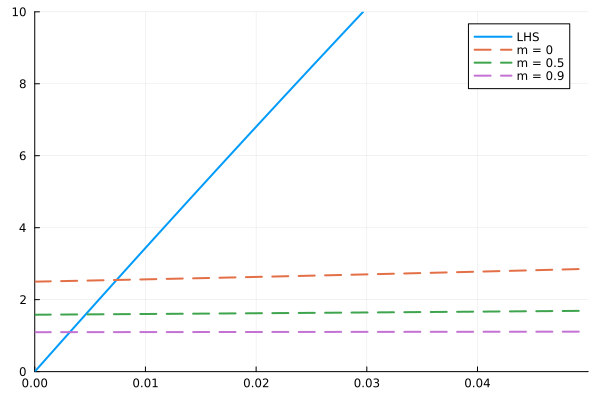

(0.007393298812307112, 0.004603361169685166, 0.0031703791389489566)

In [21]:
visulize_equilibrium_state_2D(total_population,λ,ν,0,0.5,0.9)

## Largest PDE eigen v.s. wave number k

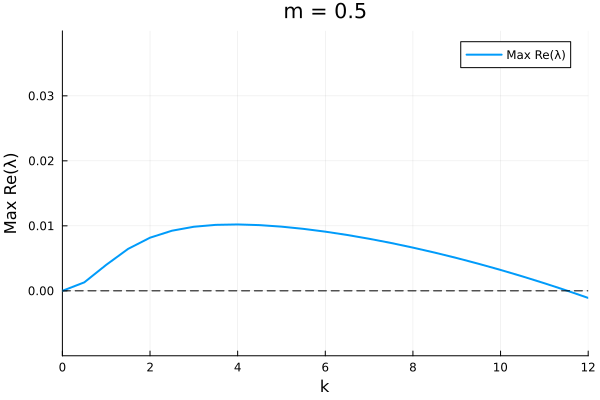

In [6]:
k_range = 0:0.5:12
plot_pde_eigenvalues_2D(total_population, λ, ν, m, d₁, d₂, k_range, (0, 12), (-0.01, 0.04))

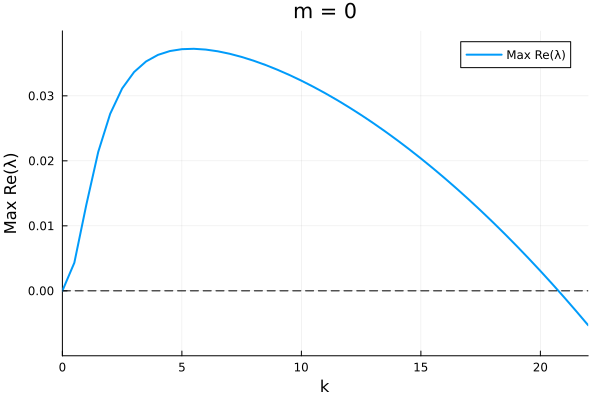

In [20]:
k_range = 0:0.5:22
m=0
plot_pde_eigenvalues_2D(total_population, λ, ν, m, d₁, d₂, k_range, (0, 22), (-0.01, 0.04))

In [13]:
function plot_eigenvalue_heatmap(save_path, Nₜ, λ, ν, d₁, d₂, m_range, k_range)
    heatmap_data = zeros(length(m_range), length(k_range))

    for (i, m) in enumerate(m_range)
        for (j, k) in enumerate(k_range)
            result = ODE_PDE_system_2D(Nₜ, λ, ν, m, d₁, d₂, k)[1]
            heatmap_data[i, j] = max(result[2], 0)  # max Re(λ)
        end
    end

    fig, ax = subplots()

    # Display heatmap
    c = ax.imshow(
        heatmap_data, 
        origin="lower", 
        aspect="auto",
        extent=[minimum(k_range), maximum(k_range), minimum(m_range), maximum(m_range)],
        cmap="hot"   # Or use "autumn", "YlOrRd", etc.
    )

    # Labels
    ax.set_xlabel("k")
    ax.set_ylabel("m")

    # Move tick marks out
    ax.tick_params(direction="out")

    # Optional: control tick frequency
    ax.set_xticks(range(minimum(k_range), stop=maximum(k_range), length=5))
    ax.set_yticks(range(minimum(m_range), stop=maximum(m_range), length=5))

    # Add colorbar
    fig.colorbar(c, ax=ax)

    tight_layout()
    PyPlot.savefig(save_path, dpi=300)
end

plot_eigenvalue_heatmap (generic function with 2 methods)

In [14]:
k_range = 0:0.5:22
m_range = 0:0.01:1
plot_eigenvalue_heatmap("2D_eigen_k_m", total_population, λ, ν, d₁, d₂, m_range, k_range)
## plot_eigenvalue_heatmap(total_population, λ, ν, d₁, d₂, m_range, k_range)

## Equilibrium points

In [5]:
N̄, P̄ =  equilibrium_state_2D([total_population],λ,ν,m)
N̄, P̄=N̄[1], P̄[1]

(0.004603361169685166, 0.39539663883031484)

## HeatMap with various total population and ODE Stability

In [7]:
Nₜ=0.1:0.01:1
d₂_vec=0:0.0001:0.004
PDE_eigen = zeros(Float64, length(d₂_vec), length(Nₜ))

for i in 1:length(d₂_vec)
    for j in 1:length(Nₜ)
        _, PDE_eigen[i,j], _ = ODE_PDE_system_2D(Nₜ, λ, ν, m, d₁, d₂_vec[i], k)[j]
    end
end

In [12]:
using PyPlot

# Assume you already computed PDE_eigen
fig, ax = subplots()

# Set white background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Use a red-yellow colormap like 'autumn' or 'hot'
c = ax.imshow(max.(PDE_eigen, 0), 
              extent=[minimum(Nₜ), maximum(Nₜ),minimum(d₂_vec), maximum(d₂_vec)],
              aspect="auto", origin="lower", cmap="hot")  # Try 'hot' or 'YlOrRd' if preferred

# Add colorbar
fig.colorbar(c, ax=ax)

# Axis labels
xlabel("Nₜ")
ylabel("d₂")

# Move tick marks outside
tick_params(direction="out")

# Set fewer tick marks manually (adjust as needed)
ax.set_xticks(range(minimum(Nₜ), stop=maximum(Nₜ), length=5))
ax.set_yticks(range(minimum(d₂_vec), stop=maximum(d₂_vec), length=5))

tight_layout()
PyPlot.savefig("2D_heatmap_PDE_eigen.png", dpi=300, facecolor=fig.get_facecolor())

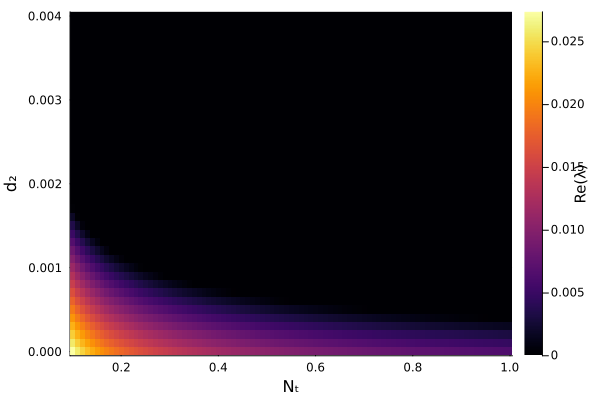

In [ ]:
heatmap(Nₜ, d₂_vec, max.(PDE_eigen, 0),
    xlabel = "Nₜ",
    ylabel = "d₂",
    colorbar = true,
)

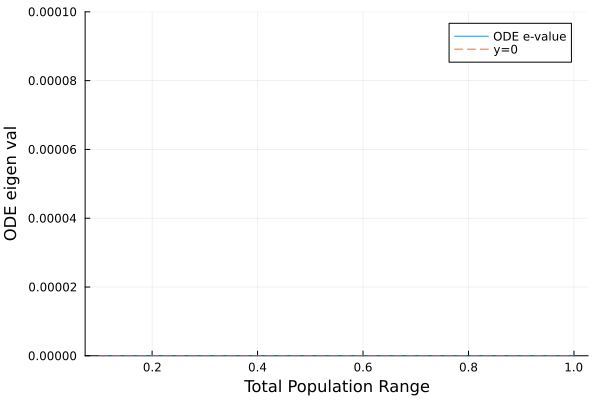

In [42]:
Nₜ=0.1:0.01:1
ODE_eigen = zeros(Float64, length(Nₜ))

for j in 1:length(Nₜ)
    ODE_eigen[j] = ODE_PDE_system_2D(Nₜ, λ, ν, 0.5, d₁, d₂, k)[j][1]
end


plot(Nₜ, ODE_eigen, xlabel="Total Population Range", ylabel="ODE eigen val", label="ODE e-value", ylim=(0,0.0001))
plot!(Nₜ, zeros(length(Nₜ)), label="y=0", linestyle=:dash)

## Initial Conditions

In [64]:
function N_initial_cond(x)
    C₁=real(ODE_PDE_system_2D(total_population,λ,ν,m,d₁,d₂,k)[1][4][1])
    N = N̄+1e-5*C₁*cos(k*x)
    return(N)
end


function P_initial_cond(x)
    C₂=real(ODE_PDE_system_2D(total_population,λ,ν,m,d₁,d₂,k)[1][4][2])
    P = P̄+1e-5*C₂*cos(k*x)
    return(P)
end;

In [18]:
function random_IC_N(x)
    noise = rand(Normal(0, 1e-4))
    return N̄ + noise
end

function random_IC_P(x)
    noise = rand(Normal(0, 1e-4))
    return P̄ + noise
end

random_IC_P (generic function with 1 method)

## Initilize and Set up Model

In [7]:
## Initialize the model
NP_parameters =   (d_1= d₁ ,
                   d_2= d₂ ,
                   ν = ν ,          
                   λ = λ
)



growth(z, t, N, P, params) = params.ν * P * N / (N + 1)
death(z,t,N,P,params)=params.λ*(max(0, P))^(1/2)


N_reaction(z, t, N, P,  params) = - growth( z, t, N, P,  params) + death(z,t,N,P,params)
P_reaction(z, t, N, P, params) =   growth( z, t, N, P, params)  - death(z,t,N,P,params)


N_forcing = Forcing(N_reaction, field_dependencies = (:N, :P), parameters = NP_parameters)
P_forcing = Forcing(P_reaction, field_dependencies = (:N, :P), parameters = NP_parameters)


grid    = RectilinearGrid(size=64, z=(0,2*π), topology=(Flat, Flat, Bounded))

diffusivities = NamedTuple{(:N, :P)}((NP_parameters.d_1, NP_parameters.d_2))

closure = ScalarDiffusivity(κ=diffusivities)

model   = NonhydrostaticModel(; grid, 
                             closure, 
                             tracers = (:N, :P),
                             forcing = (N=N_forcing, P=P_forcing)
                             )

NonhydrostaticModel{CPU, RectilinearGrid}(time = 0 seconds, iteration = 0)
├── grid: 1×1×64 RectilinearGrid{Float64, Flat, Flat, Bounded} on CPU with 0×0×3 halo
├── timestepper: RungeKutta3TimeStepper
├── advection scheme: Centered reconstruction order 2
├── tracers: (N, P)
├── closure: ScalarDiffusivity{ExplicitTimeDiscretization}(ν=0.0, κ=(N=1.0, P=0.0001))
├── buoyancy: Nothing
└── coriolis: Nothing

In [20]:
## Decide our initial condition
set!(model, N = random_IC_N, P = random_IC_P)
min_Δz = minimum_zspacing(model.grid)
diffusion_time_scale = min_Δz^2 / model.closure.κ.N

0.009638285547938826

## Simulation

In [21]:
## Running simulation
max_time=170
simulation = Simulation(model, Δt = 0.1 * diffusion_time_scale, stop_time = max_time)

########################################

N, P = model.tracers

perturbation_N(args...) = norm(N .- N̄)
perturbation_P(args...) = norm(P .- P̄)

simulation.output_writers[:growth_NP] =
    Oceananigans.OutputWriters.NetCDFOutputWriter(model, (; perturbation_N, perturbation_P);
                     filename = "2D_simu_random_parameter1/NPgrowth.nc",
                     schedule = IterationInterval(10),
                     dimensions = (; perturbation_N = (),
                                     perturbation_P = ()),
                     overwrite_existing = true)

simulation.output_writers[:fields] =
    JLD2OutputWriter(model, model.tracers,
                     filename = "2D_simu_random_parameter1/NP.jld2",
                     schedule=IterationInterval(200),
                     overwrite_existing = true)

run!(simulation)

┌ Warning: Overwriting existing .\2D_simu_random_parameter1/NPgrowth.nc.
└ @ Oceananigans.OutputWriters C:\Users\xiang\.julia\packages\Oceananigans\EYQtB\src\OutputWriters\netcdf_output_writer.jl:443
┌ Info: Initializing simulation...
└ @ Oceananigans.Simulations C:\Users\xiang\.julia\packages\Oceananigans\EYQtB\src\Simulations\run.jl:184
┌ Info:     ... simulation initialization complete (4.973 seconds)
└ @ Oceananigans.Simulations C:\Users\xiang\.julia\packages\Oceananigans\EYQtB\src\Simulations\run.jl:228
┌ Info: Executing initial time step...
└ @ Oceananigans.Simulations C:\Users\xiang\.julia\packages\Oceananigans\EYQtB\src\Simulations\run.jl:117
┌ Info:     ... initial time step complete (2.495 seconds).
└ @ Oceananigans.Simulations C:\Users\xiang\.julia\packages\Oceananigans\EYQtB\src\Simulations\run.jl:126
┌ Info: Simulation is stopping after running for 6.833 minutes.
└ @ Oceananigans.Simulations C:\Users\xiang\.julia\packages\Oceananigans\EYQtB\src\Simulations\simulation.jl:20

## Visualize Result

In [31]:
function key_variable_outcome_2D(mymodel, file_name)
    space=Array(znodes(mymodel.tracers.N))
    N_timeseries = FieldTimeSeries(file_name, "N")
    P_timeseries = FieldTimeSeries(file_name, "P")
    times=Array(N_timeseries.times)

    N_data = parent(N_timeseries.data[:,:,1:size(space)[1],:])
    P_data = parent(P_timeseries.data[:,:,1:size(space)[1],:])
    N_data = dropdims(N_data, dims=(1, 2))
    P_data = dropdims(P_data, dims=(1, 2))
    
    time_index=size(times)[1]

    N_data=N_data[:, 1:time_index]
    P_data=P_data[:, 1:time_index]

    return N_data,P_data,times,space
end

key_variable_outcome_2D (generic function with 1 method)

In [32]:
N_data,P_data,times,space=key_variable_outcome_2D(model, "2D_simu_k4_parameter1/NP.jld2");

In [27]:
using PyCall
@pyimport matplotlib.ticker as ticker
function heatmap_plot_2D(save_img_path, N_data, P_data, times, space)

    N_data_slice = N_data[:, 20:end]
    P_data_slice = P_data[:, 20:end]

    # Also slice times accordingly since you're slicing columns (assuming columns correspond to time)
    times_slice = times[20:end]

    # Determine extent with sliced data
    extent_N = [minimum(times_slice), maximum(times_slice), minimum(space), maximum(space)]
    extent_P = [minimum(times_slice), maximum(times_slice), minimum(space), maximum(space)]

    fig, axs = subplots(1, 2, figsize=(15, 6), constrained_layout=true)

    # Heatmap for N_data with actual axes
    cax1 = axs[1].imshow(N_data_slice, aspect="auto", cmap="inferno", extent=extent_N, origin="lower")
    axs[1].set_title("N", fontsize=16)
    axs[1].set_xlabel("Time", fontsize=14)
    axs[1].set_ylabel("Space", fontsize=14)

    cbar1 = fig.colorbar(cax1, ax=axs[1], shrink=0.8, aspect=20)
    cbar1.ax.tick_params(labelsize=12)
    cbar1.set_label("", fontsize=14)

    ticks1 = LinRange(cax1.get_clim()..., 6) 
    cbar1.set_ticks(ticks1)
    cbar1.set_ticklabels(string.(round.(ticks1, digits=8)))


    # Heatmap for P_data with actual axes
    cax2 = axs[2].imshow(P_data_slice, aspect="auto", cmap="inferno", extent=extent_P, origin="lower")
    axs[2].set_title("P", fontsize=16)
    axs[2].set_xlabel("Time", fontsize=14)
    axs[2].set_ylabel("Space", fontsize=14)

    # Colorbar
    cbar2 = fig.colorbar(cax2, ax=axs[2], shrink=0.8, aspect=20)
    cbar2.ax.tick_params(labelsize=12)
    cbar2.set_label("", fontsize=14)

    # Save figure
    PyPlot.savefig(save_img_path, dpi=300, bbox_inches="tight")
end



heatmap_plot_2D (generic function with 1 method)

In [30]:
using PyPlot
heatmap_plot_2D("heatmap_2D_random_p1", N_data, P_data, times, space)

In [33]:
function experiment_growth_rate(file_name, N̄, P̄, I₁, I₂)
    ds = NCDataset(file_name, "r")
    times = ds["time"][:]

    ## Denote the perturbation for N and P from the equilibrium state
    N′ = ds["perturbation_N"]
    P′ = ds["perturbation_P"]
    time_increment=170/size(times)[1]

    

    Interval_1=Int(round(I₁[1]/time_increment)):Int(round(I₁[size(I₁)[1]]/time_increment))
    Interval_2=Int(round(I₂[1]/time_increment)):Int(round(I₂[size(I₂)[1]]/time_increment))
    
    degree = 1

    ## Fit the log of growth with line on time range I for N,P
    
    linear_fit_N = fit(times[Interval_1], log.(N′[Interval_1]), degree, var = :t)
    best_fit_N = @. exp(linear_fit_N[0] + linear_fit_N[1] * times)
    
    linear_fit_P = fit(times[Interval_2], log.(P′[Interval_2]), degree, var = :t)
    best_fit_P = @. exp(linear_fit_P[0] + linear_fit_P[1] * times)

    print("Growth rate of N is approximately ", linear_fit_N[1], "\n")
    print("Growth rate of P is approximately ", linear_fit_P[1], "\n")
    print("Largest real part of e-value ", ODE_PDE_system_2D(total_population,λ,ν,m,d₁,d₂,k)[1][2])


    plot(times, N′,label="norm(N′)", yscale = :log10, linestyle=:solid,
    lw=4, xlabel="time", ylabel="norm",title="Norm of perturbations", legend=:left)

    plot!(times, P′,label="norm(P′)", linestyle=:solid, lw=4)#
    
    plot!(times, best_fit_N,label="N best fit", linestyle=:dash, lw=4)
    
    plot!(times, best_fit_P,label="P best fit", linestyle=:dash, lw=4)

end;

Growth rate of N is approximately 0.005287307645779782
Growth rate of P is approximately 0.008240804373415232
Largest real part of e-value 0.010212266571668993

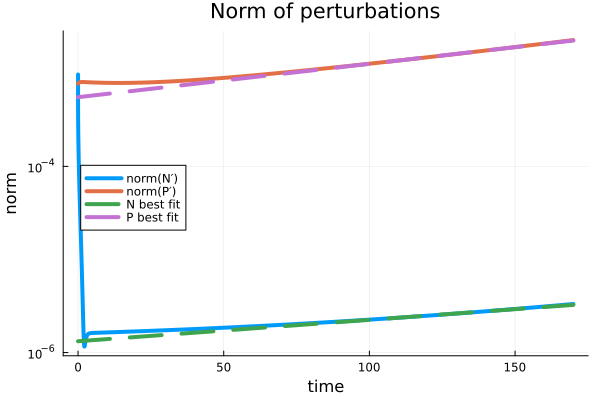

In [35]:
experiment_growth_rate("Experiment_note/NPgrowth_random.nc", N̄, P̄, 100:150, 100:150)

In [12]:

## Heatmap for power of each mode
function FFT_power_2D(save_path, N_data, P_data, N̄, P̄, times)

    perturbation_N = N_data .- N̄
    perturbation_P = P_data .- P̄
    rev_N_data=reverse(N_data, dims=1)
    N_data_mat=vcat(rev_N_data, N_data)
    fft_coeff_N_data=zeros(size(N_data_mat))

    rev_P_data=reverse(P_data, dims=1)
    P_data_mat=vcat(rev_P_data, P_data)
    fft_coeff_P_data=zeros(size(P_data_mat))

    for i in 1:size(P_data_mat)[2]
        fft_coeff_P_data[:,i]=abs.( fft(P_data_mat[:,i]) )
        fft_coeff_N_data[:,i]=abs.( fft(N_data_mat[:,i]) )
    end
    
    # === Prepare input for heatmap ===
    mode_range = 2:21
    mode_values = (mode_range .- 1) ./ 2

    # Use your heatmap plotting function
    heatmap_plot_2D(save_path,
        fft_coeff_N_data[mode_range, :],
        fft_coeff_P_data[mode_range, :],
        times,
        mode_values)
end

FFT_power_2D (generic function with 2 methods)

In [18]:
using PyPlot
FFT_power_2D("fft_modes_2D_k4_p1", N_data[:,20:end], P_data[:,20:end], N̄, P̄, times[20:end])